In [102]:
# ADABOOST (ADAPTIVE BOOSTING) ÖZET:
# - Nedir?: Yanlış tahmin edilen verilere her adımda daha fazla AĞIRLIK vererek eğitilen zayıf modeller topluluğudur.
# - Nasıl Çalışır?: Her yeni model, bir önceki modelin YANLIŞ bildiği verilere odaklanacak şekilde ağırlıkları güncellenerek eğitilir.
# - Neden Kullanılır?: Overfitting riski düşüktür, basit karar ağaçlarını birleştirip hızlı ve güçlü bir modele dönüştürür.
# - Ne Zaman?: Temel karar ağaçları yetersiz kaldığında ve gürültüsüz/orta boyutlu tablosal verilerde hızlı sonuç almak istendiğinde kullanılır.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('17-cardekho (1).csv')

In [3]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [4]:
df = df.drop('Unnamed: 0',axis=1)

In [5]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  object 
 1   brand              15411 non-null  object 
 2   model              15411 non-null  object 
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  object 
 6   fuel_type          15411 non-null  object 
 7   transmission_type  15411 non-null  object 
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.5+ MB


In [7]:
# dtype larda bir sorun yok gibi gozukuyor 

In [8]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [9]:
# seats da sifir var bunu bakaicam

In [10]:
df['seats'].value_counts()

seats
5    12910
7     1922
8      311
6      127
4       77
9       55
2        7
0        2
Name: count, dtype: int64

In [11]:
df.isnull().sum()

car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [12]:
df[df.duplicated()]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
197,Honda City,Honda,City,8,70000,Individual,Petrol,Manual,16.80,1497,116.30,5,545000
360,Maruti Baleno,Maruti,Baleno,2,5000,Individual,Petrol,Automatic,21.40,1197,83.10,5,686000
1353,Maruti Swift Dzire,Maruti,Swift Dzire,4,50000,Individual,Diesel,Manual,28.40,1248,74.02,5,680000
1429,Maruti Wagon R,Maruti,Wagon R,13,100000,Individual,Petrol,Manual,18.90,1061,67.00,5,150000
1485,Hyundai i20,Hyundai,i20,3,50000,Individual,Petrol,Manual,18.60,1197,81.83,5,625000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15229,Maruti Swift,Maruti,Swift,8,80000,Individual,Diesel,Manual,22.90,1248,74.00,5,350000
15324,Maruti Wagon R,Maruti,Wagon R,6,50000,Individual,CNG,Manual,26.60,998,58.16,5,450000
15367,Tata Tiago,Tata,Tiago,4,30000,Individual,Petrol,Manual,23.84,1199,84.00,5,350000
15378,Hyundai Grand,Hyundai,Grand,6,30000,Individual,Petrol,Manual,18.90,1197,82.00,5,450000


In [13]:
# tekrar eden verileri silecegim 

In [14]:
df = df.drop_duplicates(keep='first',ignore_index=True)

In [15]:
df[df.duplicated]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price


In [16]:
# koltuk sayisi sifir olanalri 5 esitleyecem cunklu en cok 5 li deger vardir 

In [17]:
df[df['seats'] == 0]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
3207,Honda City,Honda,City,18,40000,Individual,Petrol,Manual,13.00,1493,100.00,0,115000
12504,Nissan Kicks,Nissan,Kicks,2,10000,Individual,Diesel,Manual,19.39,1461,108.49,0,1154000


In [18]:
df.loc[df['seats'] == 0 , 'seats'] = 5 

In [19]:
df[df['seats'] == 0]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price


In [20]:
df['seats'].value_counts() # artik 0 koltuk sayisina sahip aracimiz kalmdi

seats
5    12769
7     1902
8      310
6      125
4       76
9       55
2        7
Name: count, dtype: int64

In [21]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15244.000000,1.524400e+04,15244.000000,15244.000000,15244.000000,15244.000000,1.524400e+04
mean,6.041131,5.563958e+04,19.697333,1486.171543,100.607652,5.326817,7.747014e+05
std,3.016228,5.176630e+04,4.169307,520.419390,42.915687,0.806464,8.946761e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,2.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.590000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [22]:
# count degerlermiz e li gozukuyor bunun sebebi pandastir bunu degisterebilriiz

In [23]:
pd.set_option('display.float_format','{:.4f}'.format)

In [24]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15244.0000,15244.0000,15244.0000,15244.0000,15244.0000,15244.0000,15244.0000
mean,6.0411,55639.5823,19.6973,1486.1715,100.6077,5.3268,774701.4481
std,3.0162,51766.2993,4.1693,520.4194,42.9157,0.8065,894676.0819
min,0.0000,100.0000,4.0000,793.0000,38.4000,2.0000,40000.0000
25%,4.0000,30000.0000,17.0000,1197.0000,74.0000,5.0000,385000.0000
50%,6.0000,50000.0000,19.6700,1248.0000,88.5000,5.0000,559000.0000
75%,8.0000,70000.0000,22.7000,1582.0000,117.3000,5.0000,825000.0000
max,29.0000,3800000.0000,33.5400,6592.0000,626.0000,9.0000,39500000.0000


In [25]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.7000,796,46.3000,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.9000,1197,82.0000,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.0000,1197,80.0000,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.9200,998,67.1000,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.7700,1498,98.5900,5,570000


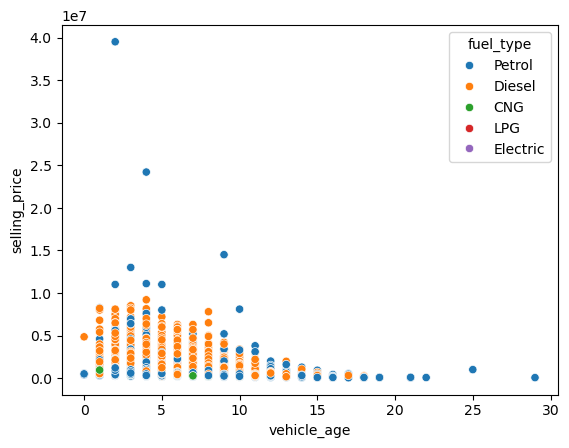

In [26]:
sns.scatterplot(x=df['vehicle_age'],y=df['selling_price'],hue=df['fuel_type'])
plt.show()

In [27]:
# cok uclarda degerlermiz var ve buda tablomuzun yapisini cok fazla bozuyor

In [28]:
df['selling_price'].value_counts()

selling_price
450000     349
550000     327
650000     326
350000     310
500000     266
          ... 
1005000      1
1965000      1
639000       1
5150000      1
702000       1
Name: count, Length: 1086, dtype: int64

In [29]:
df['selling_price'].max()

39500000

In [30]:
# selling sutunun ortalamsi 77 bin ama max degerimiz 35 milyon ve 24 milyon degerimizde cok bozuyor bundan dolayi filtreleme yapicaz

In [31]:
df = df[df['selling_price'] < 15000000]

In [32]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15242.0000,15242.0000,15242.0000,15242.0000,15242.0000,15242.0000,15242.0000
mean,6.0415,55646.3058,19.6990,1485.6811,100.5445,5.3270,770623.8601
std,3.0162,51766.3672,4.1669,518.4525,42.5621,0.8064,816170.0239
min,0.0000,100.0000,6.0000,793.0000,38.4000,2.0000,40000.0000
25%,4.0000,30000.0000,17.0000,1197.0000,74.0000,5.0000,385000.0000
50%,6.0000,50000.0000,19.6700,1248.0000,88.5000,5.0000,559000.0000
75%,8.0000,70000.0000,22.7000,1582.0000,117.3000,5.0000,825000.0000
max,29.0000,3800000.0000,33.5400,5998.0000,626.0000,9.0000,14500000.0000


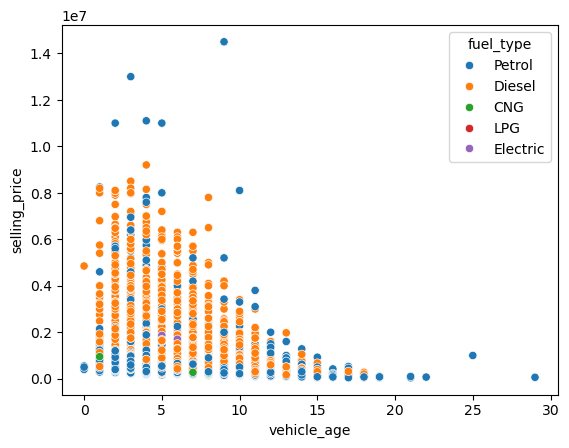

In [33]:
sns.scatterplot(x=df['vehicle_age'],y=df['selling_price'],hue=df['fuel_type'])
plt.show()

In [34]:
# grafigimiz daha anlamli bir hale geldi artik

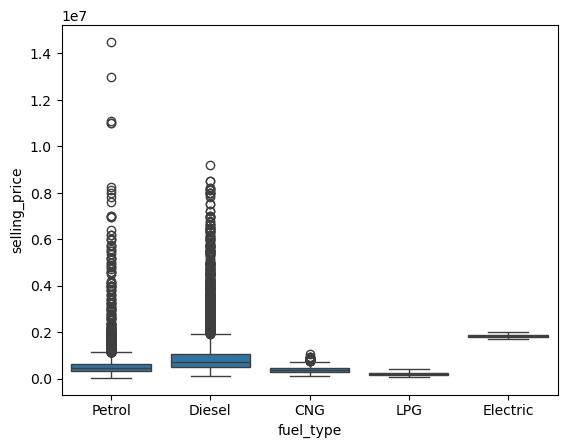

In [35]:
sns.boxplot(data=df,x='fuel_type',y='selling_price')
plt.show()

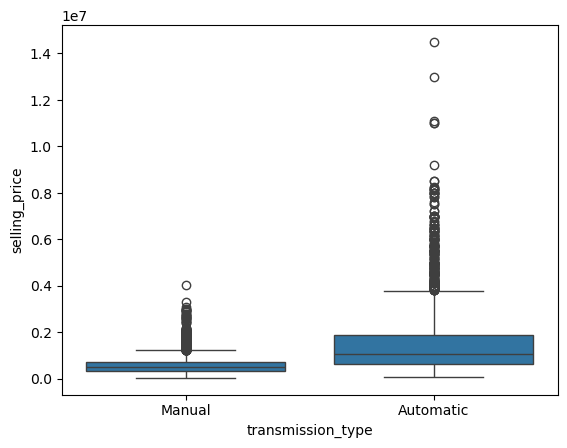

In [36]:
sns.boxplot(data=df,x='transmission_type',y='selling_price')
plt.show()

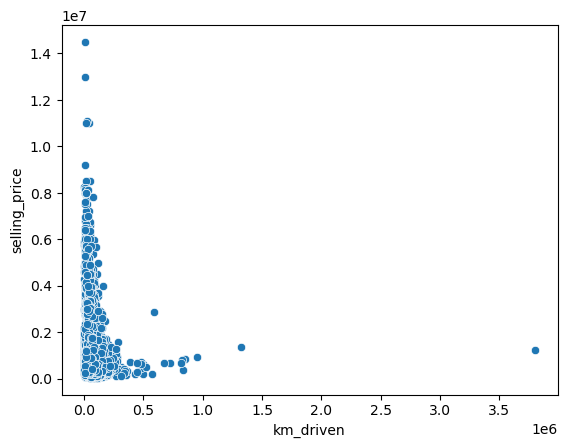

In [37]:
sns.scatterplot(data=df,x='km_driven',y='selling_price')
plt.show()

In [38]:
df['km_driven'].max()

3800000

In [39]:
# burada gene vermizi bozan asiri bir deger var bundan dolayi filtreleme yapicam 

In [40]:
df = df[(df['km_driven'] < 1000000)]

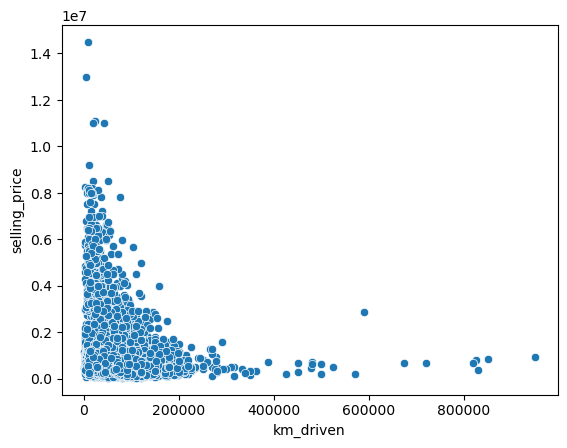

In [41]:
sns.scatterplot(data=df,x='km_driven',y='selling_price')
plt.show()

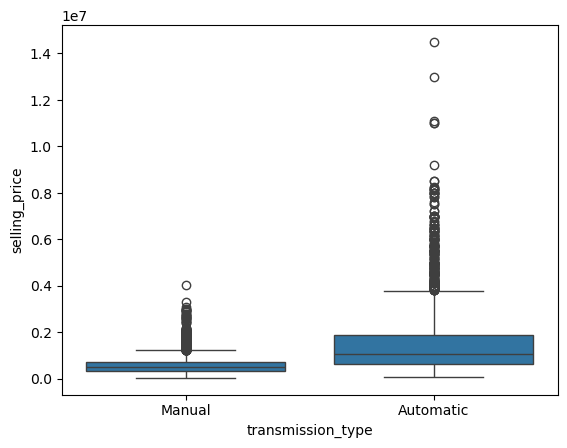

In [42]:
sns.boxplot(data=df,x='transmission_type',y='selling_price')
plt.show()

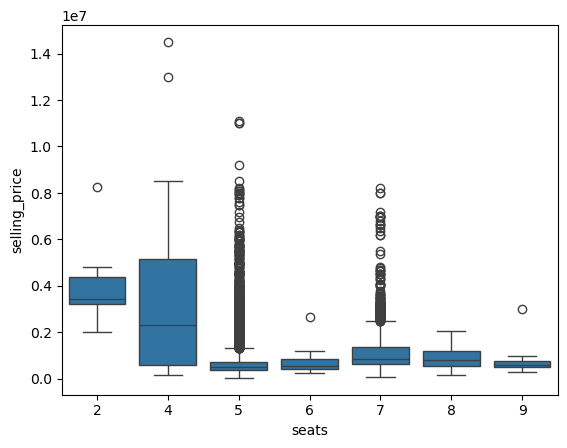

In [43]:
sns.boxplot(data=df,x='seats',y='selling_price')
plt.show()

In [44]:
df.corr(numeric_only=True)

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
vehicle_age,1.0000,0.4235,-0.2582,0.0998,0.0058,0.0313,-0.2591
km_driven,0.4235,1.0000,-0.1248,0.2335,0.0485,0.2326,-0.1095
mileage,-0.2582,-0.1248,1.0000,-0.6323,-0.5323,-0.4430,-0.3186
engine,0.0998,0.2335,-0.6323,1.0000,0.8065,0.5569,0.6118
max_power,0.0058,0.0485,-0.5323,0.8065,1.0000,0.1768,0.7732
seats,0.0313,0.2326,-0.4430,0.5569,0.1768,1.0000,0.1348
selling_price,-0.2591,-0.1095,-0.3186,0.6118,0.7732,0.1348,1.0000


In [45]:
X = df.drop('selling_price',axis=1)
y = df['selling_price']

In [46]:
X.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.7000,796,46.3000,5
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.9000,1197,82.0000,5
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.0000,1197,80.0000,5
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.9200,998,67.1000,5
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.7700,1498,98.5900,5


In [47]:
from sklearn.model_selection import train_test_split

In [48]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state = 15)
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: (10668, 12)
y_train: (10668,)


In [49]:
cat_cols = df.select_dtypes('object').columns.to_list()

In [50]:
cat_cols

['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

In [51]:
unique_values = df[cat_cols].nunique()

In [52]:
unique_values

car_name             119
brand                 30
model                118
seller_type            3
fuel_type              5
transmission_type      2
dtype: int64

In [53]:
# seller_type  , fuel_type , transmission_type -> onehotencoding (sayilari cok az )
# car_name,brand,model -> frequency encoding  

In [54]:
# Kategorik Değişken
#   │
#   ├── 1. Sıralı mı? (Eğitim seviyesi, unvan, kıdem...)
#   │     └── EVET ──> Ordinal / Label Encoding (1, 2, 3...)
#   │
#   └── 2. Sırasız mı? (Şehir, renk, departman...)
#         │
#         ├── Kategori Sayısı Az (2-15 arası) ──> One-Hot Encoding
#         │
#         └── Kategori Sayısı Fazla (15-20+)
#               │
#               ├── Ağaç Modelleri (XGBoost, LightGBM, Random Forest)
#               │     └── ──> Frequency Encoding veya Target Encoding
#               │
#               └── Doğrusal Modeller / Sinir Ağları
#                     └── ──> Target Encoding veya Embeddings
# # hatirlatma agaci koydum 1 tane ne tur verilerde hangisini yapmamiz dogru olacagina boyle kara veriyoruz 


In [55]:
 X_train['car_name'].value_counts()/len(X_train)  # frequency degerlerini bu sekilde alabiliriz 

car_name
Hyundai i20          0.0594
Maruti Swift Dzire   0.0555
Maruti Swift         0.0512
Maruti Alto          0.0499
Honda City           0.0491
                      ...  
Lexus NX             0.0001
Porsche Macan        0.0001
Tata Altroz          0.0001
Isuzu MUX            0.0001
Maserati Ghibli      0.0001
Name: count, Length: 116, dtype: float64

In [56]:
# diger verilderde kullanabilcegimiz bir kod yaptirdim yapay zekaya 

In [57]:
onehot_columns = ['seller_type','fuel_type','transmission_type']
freq_columns = ['car_name','brand','model']

In [58]:
for col in freq_columns:
    freq = X_train[col].value_counts() / len(X_train)

    X_train[col + 'freq'] = X_train[col].map(freq)

    X_test[col + 'freq'] = X_test[col].map(freq)

    mean_freq = freq.mean()
    X_test[col + 'freq'] = X_test[col + 'freq'].fillna(mean_freq)

    # kodu kaydetmeyi unutma 

In [59]:
X_train.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,car_namefreq,brandfreq,modelfreq
6205,Mahindra XUV500,Mahindra,XUV500,2,18000,Individual,Diesel,Manual,15.1000,2179,152.8700,7,0.0221,0.0668,0.0221
7707,Tata Nexon,Tata,Nexon,4,25000,Individual,Petrol,Manual,17.0000,1198,108.5000,5,0.0053,0.0277,0.0053
5332,Mahindra XUV500,Mahindra,XUV500,4,58500,Dealer,Diesel,Manual,16.0000,2179,140.0000,7,0.0221,0.0668,0.0221
2935,Maruti Eeco,Maruti,Eeco,6,59000,Dealer,Petrol,Manual,15.1000,1196,73.0000,7,0.0076,0.3212,0.0076
6419,Maruti Baleno,Maruti,Baleno,4,32000,Dealer,Petrol,Manual,21.0100,1197,81.8000,5,0.0241,0.3212,0.0241


In [60]:
X_test.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,car_namefreq,brandfreq,modelfreq
10573,Hyundai i10,Hyundai,i10,7,90000,Dealer,Petrol,Manual,19.8100,1086,68.0500,5,0.0264,0.1962,0.0264
4407,Ford Ecosport,Ford,Ecosport,4,45000,Individual,Diesel,Manual,23.0000,1498,98.9600,5,0.0255,0.0507,0.0255
5654,Maruti Baleno,Maruti,Baleno,4,71000,Dealer,Diesel,Manual,27.3900,1248,74.0000,5,0.0241,0.3212,0.0241
13787,Volkswagen Vento,Volkswagen,Vento,4,37959,Dealer,Petrol,Automatic,18.1900,1197,103.2000,5,0.0159,0.0404,0.0159
1156,Maruti Ciaz,Maruti,Ciaz,2,15260,Dealer,Diesel,Manual,28.0900,1248,88.5000,5,0.0224,0.3212,0.0224


In [61]:
X_train = X_train.drop(['car_name','brand','model'],axis=1)
X_test = X_test.drop(['car_name','brand','model'],axis = 1)

In [62]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [63]:
transformer = ColumnTransformer(
    transformers=[
        ('onehot',OneHotEncoder(drop='first',handle_unknown='ignore'),onehot_columns)
    ] , remainder = 'passthrough' 
)

In [64]:
X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

In [65]:
encoded_cols = transformer.get_feature_names_out()

In [66]:
encoded_cols

array(['onehot__seller_type_Individual',
       'onehot__seller_type_Trustmark Dealer', 'onehot__fuel_type_Diesel',
       'onehot__fuel_type_Electric', 'onehot__fuel_type_LPG',
       'onehot__fuel_type_Petrol', 'onehot__transmission_type_Manual',
       'remainder__vehicle_age', 'remainder__km_driven',
       'remainder__mileage', 'remainder__engine', 'remainder__max_power',
       'remainder__seats', 'remainder__car_namefreq',
       'remainder__brandfreq', 'remainder__modelfreq'], dtype=object)

In [67]:
X_train = pd.DataFrame(X_train,columns=encoded_cols)
X_test = pd.DataFrame(X_test,columns=encoded_cols)

In [68]:
X_train.head()

,onehot__seller_type_Individual,onehot__seller_type_Trustmark Dealer,onehot__fuel_type_Diesel,onehot__fuel_type_Electric,onehot__fuel_type_LPG,onehot__fuel_type_Petrol,onehot__transmission_type_Manual,remainder__vehicle_age,remainder__km_driven,remainder__mileage,remainder__engine,remainder__max_power,remainder__seats,remainder__car_namefreq,remainder__brandfreq,remainder__modelfreq
0,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,2.0000,18000.0000,15.1000,2179.0000,152.8700,7.0000,0.0221,0.0668,0.0221
1,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,4.0000,25000.0000,17.0000,1198.0000,108.5000,5.0000,0.0053,0.0277,0.0053
2,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,4.0000,58500.0000,16.0000,2179.0000,140.0000,7.0000,0.0221,0.0668,0.0221
3,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,6.0000,59000.0000,15.1000,1196.0000,73.0000,7.0000,0.0076,0.3212,0.0076
4,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,4.0000,32000.0000,21.0100,1197.0000,81.8000,5.0000,0.0241,0.3212,0.0241


In [69]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10668 entries, 0 to 10667
Data columns (total 16 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   onehot__seller_type_Individual        10668 non-null  float64
 1   onehot__seller_type_Trustmark Dealer  10668 non-null  float64
 2   onehot__fuel_type_Diesel              10668 non-null  float64
 3   onehot__fuel_type_Electric            10668 non-null  float64
 4   onehot__fuel_type_LPG                 10668 non-null  float64
 5   onehot__fuel_type_Petrol              10668 non-null  float64
 6   onehot__transmission_type_Manual      10668 non-null  float64
 7   remainder__vehicle_age                10668 non-null  float64
 8   remainder__km_driven                  10668 non-null  float64
 9   remainder__mileage                    10668 non-null  float64
 10  remainder__engine                     10668 non-null  float64
 11  remainder__max_

In [70]:
# ADABOOST 

In [71]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.model_selection import RandomizedSearchCV

In [72]:
model = AdaBoostRegressor()

In [73]:
model.fit(X_train,y_train)

AdaBoostRegressor()

In [74]:
y_pred = model.predict(X_test)

In [76]:
print('r2 score',r2_score(y_pred,y_test))
print('mean squared error',mean_squared_error(y_pred,y_test))
print('mean absolute error ', mean_absolute_error(y_pred,y_test))

r2 score 0.6505875014792198
mean squared error 184720460872.85214
mean absolute error  320561.17600236094


In [87]:
params = {
    'n_estimators': [50,80,100,120],
    'learning_rate':[0.001,0.01,0.1,1.0,2.0],
    'loss' : ['linear','squared','exponential']
}

In [88]:
rcv = RandomizedSearchCV(estimator=AdaBoostRegressor(),param_distributions=params,scoring='r2',cv=5)

In [89]:
# RandomizedSearchCV Ne İşe Yarar?
# 1. estimator: Optimize edilecek modeli belirler (AdaBoostRegressor).
# 2. param_distributions: Denenecek hiperparametre listesini (params) modele verir.
# 3. scoring: Modelin başarısını ölçecek metriği seçer (R2 Skoru).
# 4. cv=5: Veriyi 5 parçaya bölerek çapraz doğrulama (Cross-Validation) yapar, ezberlemeyi (overfitting) önler.
# Özet: Modelin en iyi parametrelerini rastgele deneyerek hızlıca bulmamızı sağlar.

In [90]:
rcv.fit(X_train,y_train)

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\PC\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_par

RandomizedSearchCV(cv=5, estimator=AdaBoostRegressor(),
                   param_distributions={'learning_rate': [0.001, 0.01, 0.1, 1.0,
                                                          2.0],
                                        'loss': ['linear', 'squared',
                                                 'exponential'],
                                        'n_estimators': [50, 80, 100, 120]},
                   scoring='r2')

In [91]:
rcv.best_params_

{'n_estimators': 50, 'loss': 'exponential', 'learning_rate': 0.1}

In [92]:
y_pred= rcv.predict(X_test)

In [93]:
print('r2 score',r2_score(y_pred,y_test))
print('mean squared error',mean_squared_error(y_pred,y_test))
print('mean absolute error ', mean_absolute_error(y_pred,y_test))

r2 score 0.7430008371691946
mean squared error 128558693619.01004
mean absolute error  223777.6937027307


In [94]:
#  r2 score skorumuzu %64 e kadar cikartik guzel bir yukselme oldu 

In [96]:
params = {
    'estimator__max_depth' : [3,4,5],
    'n_estimators': [50,80,100,120],
    'learning_rate':[0.001,0.01,0.1,1.0,2.0],
    'loss' : ['linear','squared','exponential']
}

In [97]:
rcv = RandomizedSearchCV(estimator=AdaBoostRegressor(DecisionTreeRegressor()),param_distributions=params,scoring='r2',cv=5)

In [98]:
rcv.fit(X_train,y_train)

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\PC\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_par

RandomizedSearchCV(cv=5,
                   estimator=AdaBoostRegressor(estimator=DecisionTreeRegressor()),
                   param_distributions={'estimator__max_depth': [3, 4, 5],
                                        'learning_rate': [0.001, 0.01, 0.1, 1.0,
                                                          2.0],
                                        'loss': ['linear', 'squared',
                                                 'exponential'],
                                        'n_estimators': [50, 80, 100, 120]},
                   scoring='r2')

In [99]:
y_pred= rcv.predict(X_test)
print('r2 score',r2_score(y_pred,y_test))
print('mean squared error',mean_squared_error(y_pred,y_test))
print('mean absolute error ', mean_absolute_error(y_pred,y_test))

r2 score 0.8801931267416214
mean squared error 67812055049.9577
mean absolute error  145092.6078111688


In [100]:
# Neden DecisionTreeRegressor() Ekledik?
# AdaBoost tek başına çalışmaz; arkasında zayıf modeller (karar ağaçları) kullanır.
# İçine açıkça tanımlayınca, AdaBoost'un varsayılan sınırlamalarını kaldırıp 
# Karar Ağacı'nın kendi derinliğini (max_depth) ve dallanmasını da optimize edebilir hale geldik.

In [101]:
# ve cok daha iyi bir r2 scoru elde etmis olduk vermizde
